# Airbnb Market Intelligence

# 05 - Time Series EDA

## Objectives

- Analyze review trends over time
- Identify yearly and monthly patterns
- Observe seasonality

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
reviews = pd.read_csv("../data/cleaned/reviews_cleaned.csv")

reviews["date"] = pd.to_datetime(reviews["date"])

reviews.head()

,listing_id,review_id,date,reviewer_id
0,11798,330265172,2018-09-30,11863072
1,15383,330103585,2018-09-30,39147453
2,16455,329985788,2018-09-30,1125378
3,17919,330016899,2018-09-30,172717984
4,26827,329995638,2018-09-30,17542859


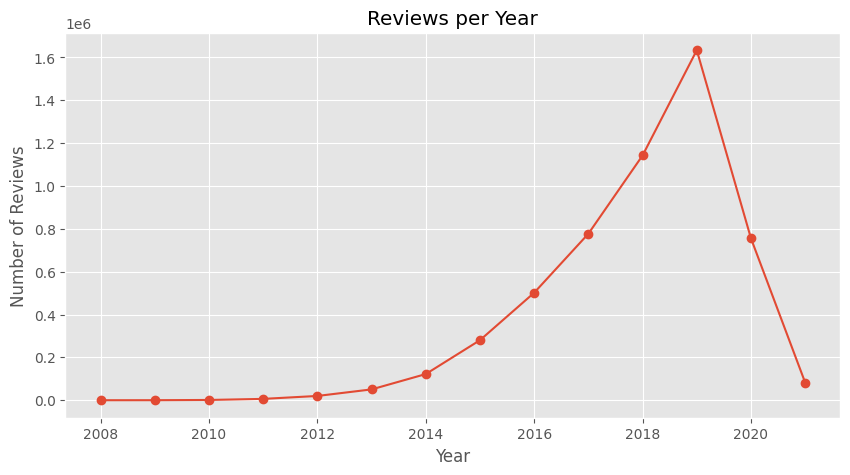

In [3]:
reviews["year"] = reviews["date"].dt.year

yearly = reviews.groupby("year").size()

plt.figure(figsize=(10,5))

yearly.plot(marker="o")

plt.title("Reviews per Year")

plt.xlabel("Year")

plt.ylabel("Number of Reviews")

plt.show()

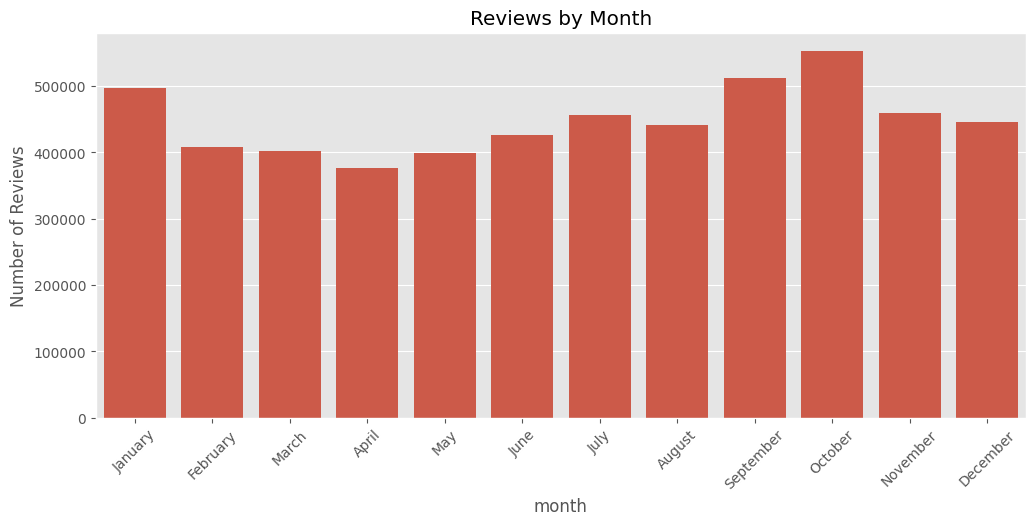

In [4]:
reviews["month"] = reviews["date"].dt.month_name()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = (
    reviews.groupby("month")
           .size()
           .reindex(month_order)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly.index,
    y=monthly.values
)

plt.xticks(rotation=45)

plt.title("Reviews by Month")

plt.ylabel("Number of Reviews")

plt.show()

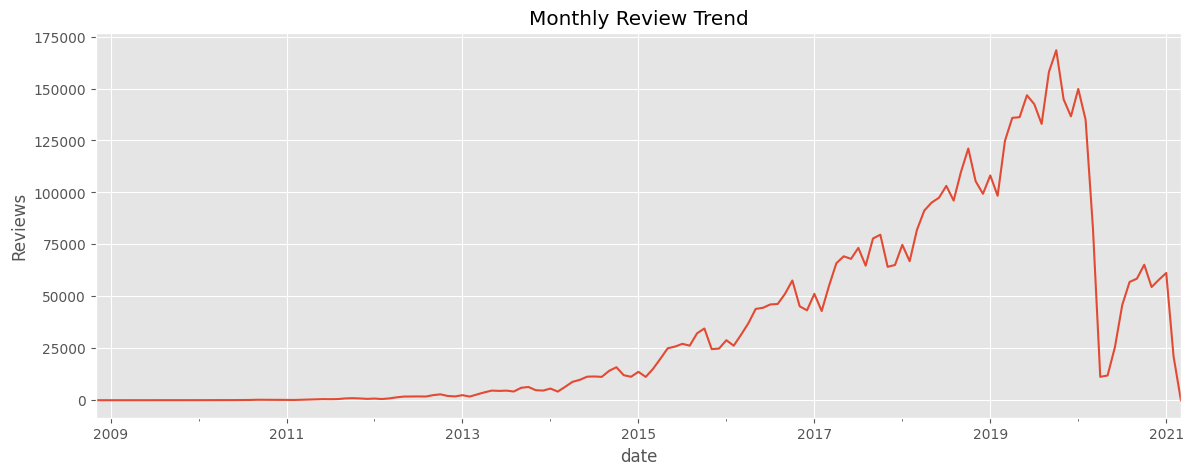

In [5]:
monthly_trend = (
    reviews.set_index("date")
           .resample("M")
           .size()
)

plt.figure(figsize=(14,5))

monthly_trend.plot()

plt.title("Monthly Review Trend")

plt.ylabel("Reviews")

plt.show()

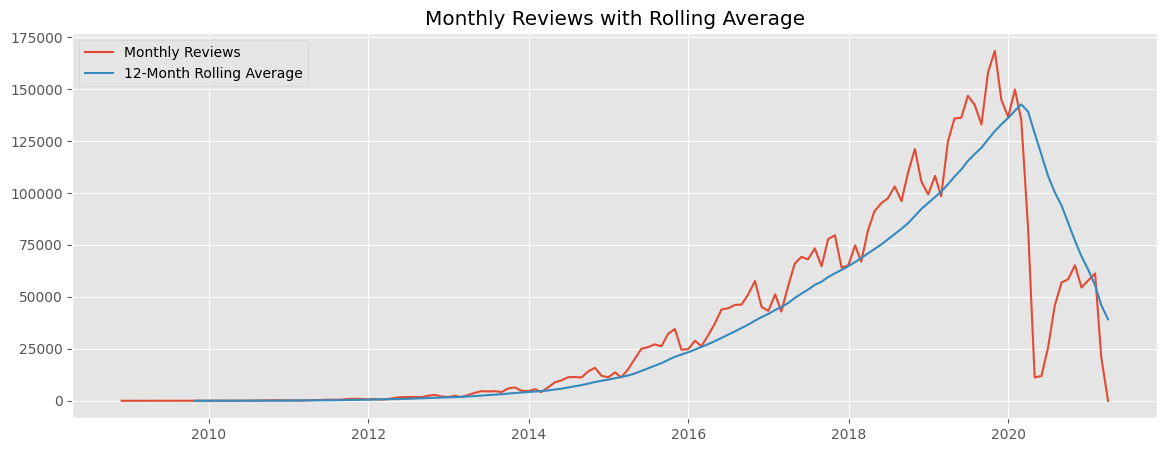

In [6]:
rolling = monthly_trend.rolling(12).mean()

plt.figure(figsize=(14,5))

plt.plot(monthly_trend,label="Monthly Reviews")

plt.plot(rolling,label="12-Month Rolling Average")

plt.legend()

plt.title("Monthly Reviews with Rolling Average")

plt.show()

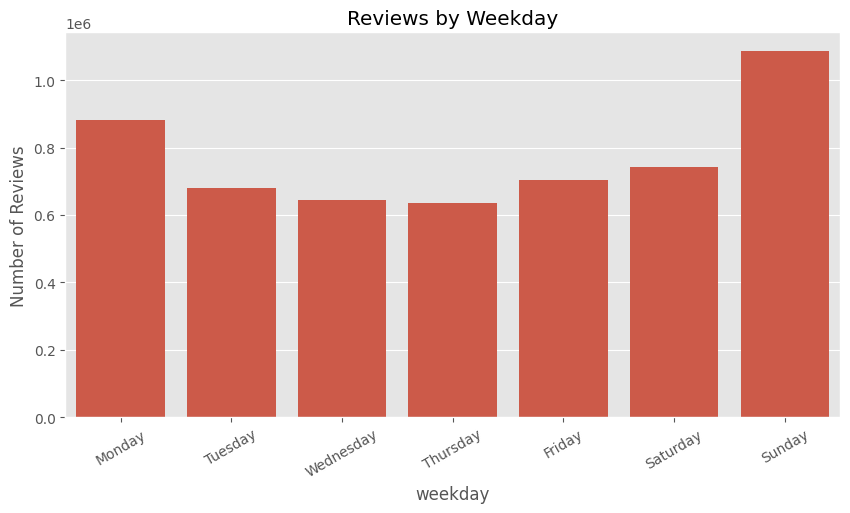

In [7]:
reviews["weekday"] = reviews["date"].dt.day_name()

weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday = (
    reviews.groupby("weekday")
           .size()
           .reindex(weekday_order)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday.index,
    y=weekday.values
)

plt.xticks(rotation=30)

plt.title("Reviews by Weekday")

plt.ylabel("Number of Reviews")

plt.show()

# Business Insights

- Review activity increased over time, indicating Airbnb's growing popularity.
- Monthly review trends reveal seasonal demand patterns.
- The rolling average highlights long-term growth while smoothing short-term fluctuations.
- Weekday review counts are relatively balanced, with slight variation across the week.